# LAB-4 POSTLAB

# Perform Regression Task on California Housing Dataset.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

# Load California Housing Dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

# Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Set Shape :", X_train.shape)
print("Testing Set Shape  :", X_test.shape)

Training Set Shape : (16512, 8)
Testing Set Shape  : (4128, 8)


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize Model
lr_model = LinearRegression()

# Train Model
lr_model.fit(X_train, y_train)

# Prediction
y_pred = lr_model.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error :", round(mae,3))
print("Mean Squared Error :", round(mse,3))
print("Root Mean Squared Error :", round(rmse,3))
print("R2 Score :", round(r2,3))

Mean Absolute Error : 0.533
Mean Squared Error : 0.556
Root Mean Squared Error : 0.746
R2 Score : 0.576


Actual vs Predicted House Prices
   Actual Price  Predicted Price
0       0.47700         0.719123
1       0.45800         1.764017
2       5.00001         2.709659
3       2.18600         2.838926
4       2.78000         2.604657
5       1.58700         2.011754
6       1.98200         2.645500
7       1.57500         2.168755
8       3.40000         2.740746
9       4.46600         3.915615


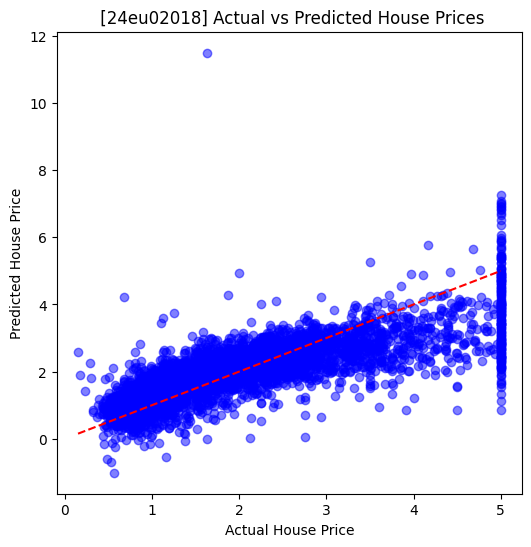

In [ ]:
import matplotlib.pyplot as plt
comparison_df = pd.DataFrame({
    "Actual Price": y_test[:10],
    "Predicted Price": y_pred[:10]
})

print("Actual vs Predicted House Prices")
print(comparison_df)

# Scatter Plot: Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Perfect prediction line
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title(" [24eu02018] Actual vs Predicted House Prices")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error",
        "Mean Squared Error",
        "Root Mean Squared Error",
        "R2 Score"
    ],
    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})

print("----- Regression Model Performance -----")
print(results.to_string(index=False))

----- Regression Model Performance -----
                 Metric    Value
    Mean Absolute Error 0.533200
     Mean Squared Error 0.555892
Root Mean Squared Error 0.745581
               R2 Score 0.575788
